In [100]:
import yaml
import pandas as pd
from glob import glob

dirs = glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-*-bf-long/*")
dirs += ["/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/test_resnet.r160_in1k-histology/e5db8c9ce8dd5b373ac0a71b72544cdc9f145b77-42"]
rows = []

for dir in dirs: 
    print(dir)
    params = yaml.safe_load(open(f"{dir}/hparams.yaml"))
    df = pd.read_csv(f"{dir}/metrics.csv")
    test_acc = df[['epoch', 'test_acc', 'test_rci_norm', 'test_rci_norm_max', 'test_rci_sim', 'test_rci_sim_min']].dropna().values
    assert len(test_acc) == 1
    if 'learnable_radial' in params['m_param']: 
        radial = params['m_param']['learnable_radial']
    else: 
        radial = False
    rows.append({
        "run_name": params['run_name'],
        "learnable_radial" : radial,
        "epoch": int(test_acc[0][0]),
        "test_acc": test_acc[0][1]*100,
        "test_rci_norm": test_acc[0][2],
        "test_rci_norm_max": test_acc[0][3],
        "test_rci_sim": test_acc[0][4],
        "test_rci_sim_min": test_acc[0][5], 
        "max_train_acc": df['train_acc'].max() * 100,
        "max_val_acc": df['val_acc'].max()*100,
    })

/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-radial-bf-long/6e57a982029748a6980afeed2828be181e8756b8-232
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-noradial-bf-long/6e57a982029748a6980afeed2828be181e8756b8-223
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-noradial-bf-long/6e57a982029748a6980afeed2828be181e8756b8-232
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-noradial-bf-long/6e57a982029748a6980afeed2828be181e8756b8-390
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/test_resnet.r160_in1k-histology/e5db8c9ce8dd5b373ac0a71b72544cdc9f145b77-42


In [101]:

print(pd.DataFrame(rows).sort_values('learnable_radial').to_markdown())

|    | run_name                             | learnable_radial   |   epoch |   test_acc |   test_rci_norm |   test_rci_norm_max |   test_rci_sim |   test_rci_sim_min |   max_train_acc |   max_val_acc |
|---:|:-------------------------------------|:-------------------|--------:|-----------:|----------------:|--------------------:|---------------:|-------------------:|----------------:|--------------:|
|  1 | prototype-histology-noradial-bf-long | False              |      81 |    88      |        0.719363 |             3.38506 |       0.99827  |           0.964508 |         99.425  |       88.2    |
|  2 | prototype-histology-noradial-bf-long | False              |      82 |    88.6    |        0.445659 |             2.57101 |       0.999183 |           0.963422 |         99.125  |       89.6    |
|  3 | prototype-histology-noradial-bf-long | False              |      81 |    88.8    |        0.498384 |             2.45711 |       0.999095 |           0.980322 |         99.05   |       

Text(0, 0.5, 'Loss')

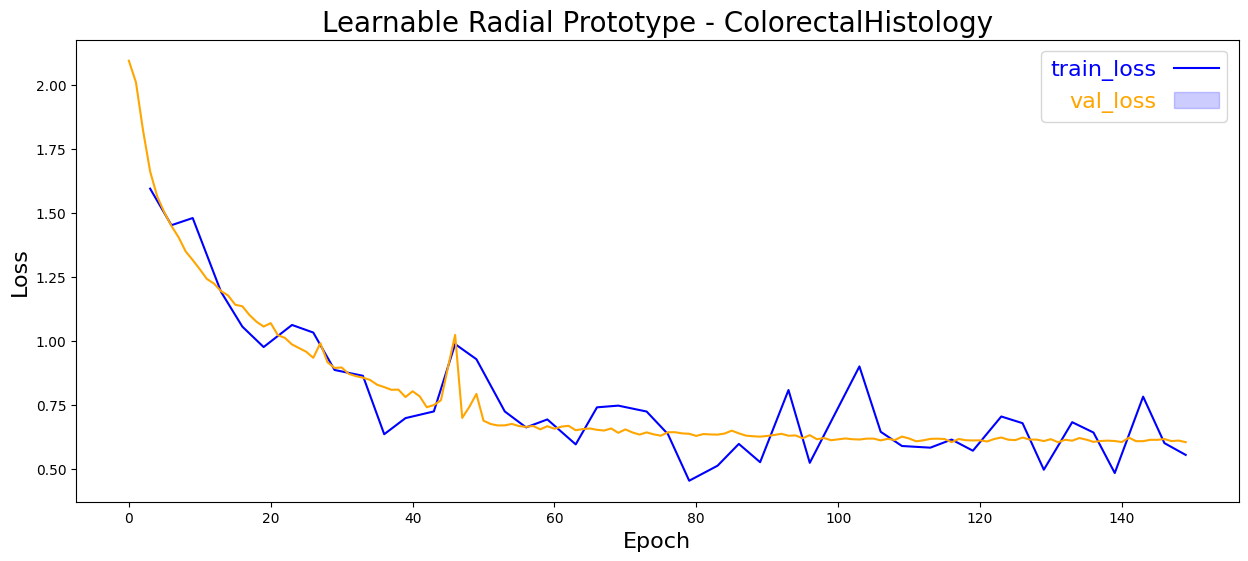

In [102]:
# plot the loss curves 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
sns.lineplot(data=df[['epoch', 'train_loss']].dropna(), x='epoch', y='train_loss', color='blue')
sns.lineplot(data=df[['epoch', 'val_loss']].dropna(), x='epoch', y='val_loss', color='orange')
plt.legend(['train_loss', 'val_loss'], fontsize=16, labelcolor=['blue', 'orange'], markerfirst=False)
plt.title("Learnable Radial Prototype - ColorectalHistology", fontsize=20)
plt.xlabel("Epoch", fontsize=16)
plt.ylabel("Loss", fontsize=16)

In [99]:
df

,epoch,lr-AdamW,step,test_acc,test_loss,test_rci_norm,test_rci_norm_max,test_rci_sim,test_rci_sim_min,train_acc,train_epoch_time,train_loss,val_acc,val_loss
0,NaN,0.01525,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.334271,NaN,NaN
2,0.0,NaN,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.031849,NaN,NaN
3,0.0,NaN,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.652,0.865052
4,0.0,NaN,124,NaN,NaN,NaN,NaN,NaN,NaN,0.51475,151.719818,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,81.0,NaN,10199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001861,NaN,NaN
448,81.0,NaN,10249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002210,NaN,NaN
449,81.0,NaN,10249,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.848,0.709717
450,81.0,NaN,10249,NaN,NaN,NaN,NaN,NaN,NaN,0.99625,153.328888,NaN,NaN,NaN
